In [109]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from typing import Callable, Optional
import sys

sys.path.append('/Users/nmehlman/Library/Mobile Documents/com~apple~CloudDocs/Desktop/CSCI 699/Project/poison-perf')
from utils.algorithms import RGD, PerfGD
from utils.experiment_setup import setup_1d_non_linear_experiment, setup_binary_classification, setup_non_convex_1d
from poisoning.oracle import oracle_poison_function, RGD_update_estimator, PerfGD_update_estimator, classification_sampling_estimator, gaussian_sampling_estimator
from utils.plotting import plot_results_1d, plot_results_2d

Alternate version of RGD that also compute the proposed convergence metric

In [ ]:
def RGD_audit(
    D_theta: Callable,
    loss: Callable,
    theta_0: torch.Tensor,
    n: int = 1000,
    eta: float = 0.1,
    max_iter: int = 100,
    proj_theta: Callable = lambda x: x,
    poison_function: Optional[Callable] = None,
    last_step_only: bool = False,
    **poison_kwargs
):
    """
    Repeated Gradient Descent algorithm with optional poisoning.
    
    Inputs:
        D_theta: Distribution function that takes theta and n, returns samples
        loss: Loss function that takes samples and theta
        theta_0: Initial parameter vector
        n: Number of samples per iteration
        eta: Learning rate
        tol: Convergence tolerance
        max_iter: Maximum number of iterations
        poison_function: Optional poisoning function
        **poison_kwargs: Additional keyword arguments for poisoning function
    
    Outputs:
        Final theta and list of all theta values during optimization
    """
    all_thetas = [theta_0.clone().detach().squeeze()]
    all_losses = []
    convergence_metrics = []
    
    theta_t = theta_0

    # Record loss on TRUE (not poisoned) distribution
    z_true = D_theta(theta_t, n)
    true_loss = loss(z_true, theta_t).mean()
    all_losses.append(true_loss.item())
    
    for t in range(max_iter):
        
        # Draw n samples from D(theta)
        z = D_theta(theta_t, n)
    
        if (poison_function is not None) and not last_step_only:
            z = poison_function(z, theta_t, eta=eta, loss=loss, proj_theta=proj_theta, **poison_kwargs)
            
        if (poison_function is not None) and last_step_only and (t == max_iter - 1):
            z = poison_function(z, theta_t, eta=eta, loss=loss, proj_theta=proj_theta, **poison_kwargs)

        # Compute gradient of loss (dL1)
        theta_t.requires_grad_(True)
        theta_t.grad = None 
        l_t = loss(z, theta_t).mean()
        l_t.backward()
        dL1 = theta_t.grad
        
        with torch.no_grad():
            theta_t = theta_t - eta * dL1 / dL1.norm()
            theta_t = proj_theta(theta_t)
        
        all_thetas.append(theta_t.detach().squeeze())

        # Record loss on TRUE (not poisoned) distribution
        z_true = D_theta(theta_t, n)
        true_loss = loss(z_true, theta_t).mean()
        all_losses.append(true_loss.item())
        
        # Compute convergence audit metric
        dLt = torch.autograd.functional.jacobian(lambda th: loss(z_true, th).squeeze(), theta_t)
        dLp = torch.autograd.functional.jacobian(lambda th: loss(z, th).squeeze(), theta_t)
        
        
        M = dLt @ dLp.T
        c = M.sum()
        convergence_metrics.append(c.item())

    return theta_t, all_thetas, all_losses, convergence_metrics

# Non-linear means

In [ ]:
a0 = 1.0
a1 = 1.0

proj_theta = lambda theta: torch.clamp(theta, min=-1.0, max=1.0)
mu, sigma, D_theta, loss, theta_0, grad2_est, f_hat, info = setup_1d_non_linear_experiment(a0=a0, a1=a1, perfGD=True)

## RGD

In [ ]:
n_trials = 10

n = 500
eta = 0.05
max_iter = 30

poison_steps = 40
poison_step_size = 1
epsilon = 1.0
delta = 30

def run_trial():
    _, all_theta_clean, all_losses_clean = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True
    )

    _, all_theta_poisoned, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                poison_function=oracle_poison_function,
                theta_update_estimator=RGD_update_estimator,
                sampling_estimator=gaussian_sampling_estimator,
                sampling_estimator_kwargs={'mu': mu, 'sigma': sigma},
                poison_steps=poison_steps,
                poison_step_size=poison_step_size,
                epsilon=epsilon,
                delta=delta,
            )

    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean) 
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

fig, (ax1, ax2) = plot_results_1d(all_theta_clean_list, 
                    all_theta_poisoned_list,
                    all_loss_clean_list, 
                    all_loss_poisoned_list
                    )

plt.show()

### Plot loss and theta gap as a function of delta

In [ ]:
delta_vals = np.linspace(0.0, 100, 100)
epsilon = 0.5
poison_step_size = 1
poison_steps = 40

theta_clean, _, all_losses_clean = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True
    )

theta_clean = theta_clean.item()
loss_clean = all_losses_clean[-1]

losses_poisoned, theta_poisoned, mean_convergence = [], [], []
for delta in delta_vals:
    _theta_poisoned, _, all_losses_poisoned, convergence_metrics = RGD_audit(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                poison_function=oracle_poison_function,
                theta_update_estimator=RGD_update_estimator,
                sampling_estimator=gaussian_sampling_estimator,
                sampling_estimator_kwargs={'mu': mu, 'sigma': sigma},
                poison_steps=int(float(delta)//poison_step_size) + 1,
                poison_step_size=poison_step_size,
                epsilon=epsilon,
                delta=delta,
    )

    losses_poisoned.append(all_losses_poisoned[-1])
    theta_poisoned.append(_theta_poisoned.item())
    mean_convergence.append(np.mean(convergence_metrics))

losses_poisoned = np.array(losses_poisoned)
theta_poisoned = np.array(theta_poisoned)
mean_convergence = np.array(mean_convergence)

# Create two subplots: top = theta gap, bottom = loss gap
fig, (ax_theta, ax_loss) = plt.subplots(2, 1, figsize=(9, 10), sharex=True)

# Theta subplot (left axis: theta gap, right axis: convergence)
ln_theta = ax_theta.plot(delta_vals, theta_poisoned - theta_clean, color='blue', label='Theta difference')
ax_theta.set_ylabel('Theta difference', color='blue')
ax_theta.tick_params(axis='y', labelcolor='blue')
ax_theta.set_title('Theta difference and convergence vs Delta')
ax_theta_right = ax_theta.twinx()
ln_conv_theta = ax_theta_right.plot(delta_vals, mean_convergence, color='green', linestyle='--', label='Mean convergence')
ax_theta_right.set_ylabel('Mean convergence', color='green')
ax_theta_right.tick_params(axis='y', labelcolor='green')
# Combined legend for theta subplot
lines = ln_theta + ln_conv_theta
labels = [l.get_label() for l in lines]
ax_theta.legend(lines, labels, loc='lower right')

# Loss subplot (left axis: loss gap, right axis: convergence)
ln_loss = ax_loss.plot(delta_vals, losses_poisoned - loss_clean, color='red', label='Loss difference')
ax_loss.set_xlabel('Delta')
ax_loss.set_ylabel('Loss difference', color='red')
ax_loss.tick_params(axis='y', labelcolor='red')
ax_loss.set_title('Loss difference and convergence vs Delta')
ax_loss_right = ax_loss.twinx()
ln_conv_loss = ax_loss_right.plot(delta_vals, mean_convergence, color='green', linestyle='--', label='Mean convergence')
ax_loss_right.set_ylabel('Mean convergence', color='green')
ax_loss_right.tick_params(axis='y', labelcolor='green')
# Combined legend for loss subplot
lines = ln_loss + ln_conv_loss
labels = [l.get_label() for l in lines]
ax_loss.legend(lines, labels, loc='lower right')

plt.tight_layout()
plt.show()

## PerfGD

In [ ]:
n_trials = 10

n = 500
eta = 0.05
max_iter = 30

poison_steps = 10
poison_step_size = 0.5
epsilon = 0.5
delta = 2.5

def run_trial():
    _, all_theta_clean, all_losses_clean = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True  
    )

    _, all_theta_poisoned, all_losses_poisoned = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                poison_function=oracle_poison_function,
                theta_update_estimator=PerfGD_update_estimator,
                poison_steps=poison_steps,
                poison_step_size=poison_step_size,
                epsilon=epsilon,
                delta=delta,
                sampling_estimator=gaussian_sampling_estimator,
                sampling_estimator_kwargs={'mu': mu, 'sigma': sigma},
    )

    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean) 
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

fig, (ax1, ax2) = plot_results_1d(all_theta_clean_list, 
                    all_theta_poisoned_list,
                    all_loss_clean_list, 
                    all_loss_poisoned_list
                    )

plt.show()

### Plot theta and loss gap vs. delta

In [ ]:
delta_vals = np.linspace(0.1, 5.0, 100)
poison_step_size = 0.5
poison_steps = 10
epsilon = 0.5

theta_clean, _, all_losses_clean = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True  
    )

theta_clean = theta_clean.item()
loss_clean = all_losses_clean[-1]

losses_poisoned, theta_poisoned = [], []
for delta in delta_vals:
    _theta_poisoned, _, all_losses_poisoned = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                poison_function=oracle_poison_function,
                theta_update_estimator=PerfGD_update_estimator,
                poison_steps=int(float(delta)//poison_step_size) + 1,
                poison_step_size=poison_step_size, 
                sampling_estimator=gaussian_sampling_estimator,
                sampling_estimator_kwargs={'mu': mu, 'sigma': sigma},
                epsilon=epsilon,
                delta=delta,
    )

    losses_poisoned.append(all_losses_poisoned[-1])
    theta_poisoned.append(_theta_poisoned.item())

losses_poisoned = np.array(losses_poisoned)
theta_poisoned = np.array(theta_poisoned)

fig, ax_left = plt.subplots()
# Left axis: theta difference
ln1 = ax_left.plot(delta_vals, theta_poisoned - theta_clean, color='blue', label='Theta difference')
ax_left.set_xlabel('Delta')
ax_left.set_ylabel('Theta difference', 
                   color='blue')
ax_left.tick_params(axis='y', labelcolor='blue')

# Right axis: loss difference
ax_right = ax_left.twinx()
ln2 = ax_right.plot(delta_vals, losses_poisoned - loss_clean, color='red', label='Loss difference')
ax_right.set_ylabel('Loss difference', color='red')
ax_right.tick_params(axis='y', labelcolor='red')

# Combined legend
lines = ln1 + ln2
labels = [l.get_label() for l in lines]
ax_left.legend(lines, labels, loc='lower right')

ax_left.set_title('Difference in Theta and Loss vs Delta')
plt.show()

# Binary Classification

In [ ]:
mu_f, mu_0, sigma_0, sigma_1, D_theta, loss, theta_0, grad2_est, f_hat = setup_binary_classification(perfGD=True)

x, y = D_theta(n=1000, theta=theta_0)

# prettier colors and styled histograms
colors = ['#4C72B0', '#DD8452']  # muted blue and warm orange

x0 = x[(y == 0).bool()].numpy()
x1 = x[(y == 1).bool()].numpy()

plt.hist(x0, bins=30, density=True, alpha=0.65, color=colors[0],
         edgecolor='k', linewidth=0.5, label='Class 0')
plt.hist(x1, bins=30, density=True, alpha=0.65, color=colors[1],
         edgecolor='k', linewidth=0.5, label='Class 1')

plt.xlabel('x')
plt.ylabel('Density')
plt.title('Sample from D(theta)')
plt.legend(frameon=True)
plt.show()

## RGD

In [ ]:
n_trials = 5

n = 500
eta = 0.05
max_iter = 30

poison_steps = 40
poison_step_size = 0.1
epsilon = 0.01
delta = 0.5

theta_0 = torch.tensor([0.8,1.0])

def run_trial():
    _, all_theta_clean, all_losses_clean = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True
    )

    _, all_theta_poisoned, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                poison_function=oracle_poison_function,
                theta_update_estimator=RGD_update_estimator,
                sampling_estimator=classification_sampling_estimator,
                sampling_estimator_kwargs={'mu_0': mu_0, 'mu_f': mu_f, 'sigma_0': sigma_0, 'sigma_1': sigma_1},
                poison_steps=poison_steps,
                poison_step_size=poison_step_size,
                epsilon=epsilon,
                delta=delta,
    )

    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean) 
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

fig, (ax1, ax2) = plot_results_2d(all_theta_clean_list, 
                    all_theta_poisoned_list,
                    all_loss_clean_list, 
                    all_loss_poisoned_list
                    )

plt.show()

### Plot theta and loss gap vs. delta

In [ ]:
delta_vals = np.linspace(0.0, 5, 50)
epsilon = 0.5
poison_step_size = 0.05
poison_steps = 10

theta_clean, _, all_losses_clean = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True
    )

theta_clean = theta_clean
loss_clean = all_losses_clean[-1]

losses_poisoned, theta_poisoned = [], []
for delta in delta_vals:
    _theta_poisoned, _, all_losses_poisoned , _ = RGD_audit(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                poison_function=oracle_poison_function,
                theta_update_estimator=RGD_update_estimator,
                sampling_estimator=classification_sampling_estimator,
                sampling_estimator_kwargs={'mu_0': mu_0, 'mu_f': mu_f, 'sigma_0': sigma_0, 'sigma_1': sigma_1},
                poison_steps=int(float(delta)//poison_step_size) + 1,
                poison_step_size=poison_step_size,
                epsilon=epsilon,
                delta=delta,
                last_step_only=False
    )

    losses_poisoned.append(all_losses_poisoned[-1])
    theta_poisoned.append(_theta_poisoned)

losses_poisoned = np.array(losses_poisoned)
theta_poisoned = np.array(theta_poisoned)

# Create two subplots: top = theta gap, bottom = loss gap
fig, (ax_theta, ax_loss) = plt.subplots(2, 1, figsize=(9, 10), sharex=False)

ax_theta.scatter(theta_clean[0], theta_clean[1], color='green', label='Clean', marker='X', s=100, zorder=5)
ax_theta.scatter(theta_poisoned[:,0], theta_poisoned[:,1], color='red', label='Poisoned', marker='o', alpha=0.5)
ax_theta.plot(theta_poisoned[:,0], theta_poisoned[:,1], color='red', alpha=0.2)
ax_theta.set_ylabel(r'$\theta_1$', color='k')
ax_theta.set_xlabel(r'$\theta_0$', color='k')
ax_theta.set_title('Theta difference')

# Combined legend for theta subplot
ax_theta.legend(loc='lower right')

# Loss subplot (left axis: loss gap, right axis: convergence)
ln_loss = ax_loss.plot(delta_vals, losses_poisoned - loss_clean, color='red', label='Loss difference')
ax_loss.set_xlabel('Delta')
ax_loss.set_ylabel('Loss difference', color='red')
ax_loss.tick_params(axis='y', labelcolor='red')
ax_loss.set_title('Loss difference vs Delta')

plt.tight_layout()
plt.show()

### Plot full poison for last step only

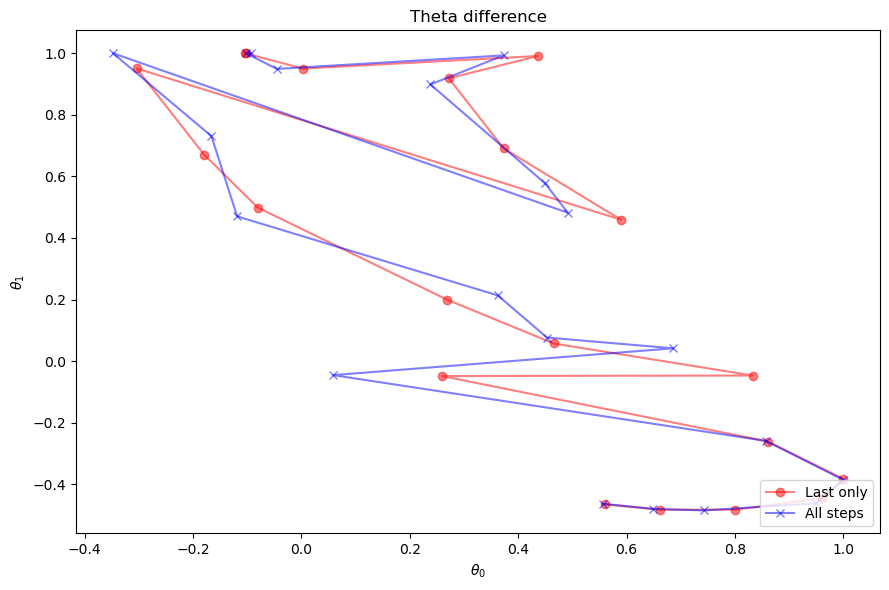

In [108]:
delta_vals = np.linspace(0.0, 3, 20)
epsilon = 0.5
poison_step_size = 0.05
poison_steps = 1

theta_clean = theta_clean
loss_clean = all_losses_clean[-1]

all_steps_theta, last_step_only = [], []
for delta in delta_vals:
    _theta_all, _, _ , _ = RGD_audit(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                poison_function=oracle_poison_function,
                theta_update_estimator=RGD_update_estimator,
                sampling_estimator=classification_sampling_estimator,
                sampling_estimator_kwargs={'mu_0': mu_0, 'mu_f': mu_f, 'sigma_0': sigma_0, 'sigma_1': sigma_1},
                poison_steps=int(float(delta)//poison_step_size) + 1,
                poison_step_size=poison_step_size,
                epsilon=epsilon,
                delta=delta,
                last_step_only=False
    )
    
    _theta_last, _, _ , _ = RGD_audit(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                poison_function=oracle_poison_function,
                theta_update_estimator=RGD_update_estimator,
                sampling_estimator=classification_sampling_estimator,
                sampling_estimator_kwargs={'mu_0': mu_0, 'mu_f': mu_f, 'sigma_0': sigma_0, 'sigma_1': sigma_1},
                poison_steps=int(float(delta)//poison_step_size) + 1,
                poison_step_size=poison_step_size,
                epsilon=epsilon,
                delta=delta,
                last_step_only=False
    )

    all_steps_theta.append(_theta_all)
    last_step_only.append(_theta_last)
    
all_steps_theta = np.array(all_steps_theta)
last_step_only = np.array(last_step_only)

# Create two subplots: top = theta gap, bottom = loss gap
fig, (ax_theta) = plt.subplots(1, 1, figsize=(9, 6), sharex=False)

ax_theta.plot(last_step_only[:,0], last_step_only[:,1], color='red', label='Last only', marker='o', alpha=0.5)
ax_theta.plot(all_steps_theta[:,0], all_steps_theta[:,1], color='blue', label='All steps', marker='x', alpha=0.5)

ax_theta.set_ylabel(r'$\theta_1$', color='k')
ax_theta.set_xlabel(r'$\theta_0$', color='k')
ax_theta.set_title('Theta difference')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Non-convex example

In [ ]:
mu, mu_0, sigma, D_theta, loss, theta_0, grad2_est, f_hat = setup_non_convex_1d(perfGD=True)    

In [ ]:
n_trials = 10

n = 500
eta = 0.05
max_iter = 30

poison_steps = 40
poison_step_size = 1
epsilon = 1.0
delta = 100

def run_trial():
    _, all_theta_clean, all_losses_clean = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                #proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True
    )

    _, all_theta_poisoned, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                #proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                poison_function=oracle_poison_function,
                theta_update_estimator=RGD_update_estimator,
                sampling_estimator=gaussian_sampling_estimator,
                sampling_estimator_kwargs={'mu': mu, 'sigma': sigma},
                poison_steps=poison_steps,
                poison_step_size=poison_step_size,
                epsilon=epsilon,
                delta=delta,
            )

    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean) 
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

fig, (ax1, ax2) = plot_results_1d(all_theta_clean_list, 
                    all_theta_poisoned_list,
                    all_loss_clean_list, 
                    all_loss_poisoned_list
                    )

plt.show()